<a href="https://colab.research.google.com/github/tommaso-colab/MD2SL/blob/main/textmining_MD2SL_Letterio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MASTER MD2SL 23-24**</br>
Text Mining  Prof. Lippi Prof. Marinai  </br>
2024-12-17 Tommaso Letterio </br></br>

# **Python Langchain for Retrieval-Augmented Generation Q&A**


https://medium.com/@onkarmishra/using-langchain-for-question-answering-on-own-data-3af0a82789ed </br> https://medium.com/@scholarly360/langchain-huggingface-complete-guide-on-colab-dfafe04fe661

[Submitted on 18 Dec 2023 (v1), last revised 27 Mar 2024 (this version, v5)] Retrieval-Augmented Generation for Large Language Models: A Survey Yunfan Gao, Yun Xiong, Xinyu Gao, Kangxiang Jia, Jinliu Pan, Yuxi Bi, Yi Dai, Jiawei Sun, Meng Wang, Haofen Wang

RAG_diagram.svg

In [ ]:
!pip install -U langchain-community
!pip install pypdf
!pip install langchain-huggingface==0.0.1 accelerate bitsandbytes
!pip install tiktoken
!pip install chromadb
!pip install -U pydantic
!pip install -U langchain
!pip install langchain chromadb transformers sentence-transformers PyPDF2

  Using cached langchain_core-0.2.43-py3-none-any.whl.metadata (6.2 kB)
Using cached langchain_core-0.2.43-py3-none-any.whl (397 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.25
    Uninstalling langchain-core-0.3.25:
      Successfully uninstalled langchain-core-0.3.25
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.12 requires langchain-core<0.4.0,>=0.3.25, but you have langchain-core 0.2.43 which is incompatible.
langchain-community 0.3.12 requires langchain-core<0.4.0,>=0.3.25, but you have langchain-core 0.2.43 which is incompatible.
langchain-text-splitters 0.3.3 requires langchain-core<0.4.0,>=0.3.25, but you have langchain-core 0.2.43 which is incompatible.
  Using cached langchain_core-0.3.25-py3-none-any.whl.metadata (6.3 kB)
Using cached langchain_core-0.3.25-py3-none-any.whl (411 kB)
  A

In [ ]:
from langchain.document_loaders import PyPDFLoader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
loader = PyPDFLoader("/content/drive/MyDrive/text_mining/jd_guns.pdf")

#Load the document by calling loader.load()
pages = loader.load()

print(len(pages))
print(pages[0].page_content[0:500])

print(pages[0].metadata)
# {'source': 'docs/cs229_lectures/MachineLearning-Lecture01.pdf', 'page': 0}

4
A SUITABLE STARTING POINT FROM WHICH TO COMPARE historical developments on the 
different continents is around 11,000 B.C.* This date corresponds approximately to the beginnings of 
village life in a few parts of the world, the first undisputed peopling of the Americas, the end of the 
Pleistocene Era and last Ice Age, and the start of what geologists term the Recent Era. Plant and animal 
domestication began in at least one part of the world within a few thousand years of that date. As of 
then
{'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}


# **TEXT SPLITTING**

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter, TokenTextSplitter

#load pages
pages = loader.load()

chunk_size = 36
chunk_overlap = 4

#token splitter
tk_splitter = TokenTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
tk_split = tk_splitter.split_documents(pages)

#Recursive char splitter:  It attempts to split text on a list of characters in order,
#falling back to the next option if the resulting chunks are too large.
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    length_function = len,
    separators=["\n\n", "\n", " ", ""]
)
docs_recur = r_splitter.split_documents(pages)

#Character splitter:  It divides text based on a specified number of characters,
#making it suitable for simple, uniform text splitting tasks.
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separator = '\n'
    )
docs_charsplitter = c_splitter.split_documents(pages)

#show output

print("---nr of splits")
print(len(tk_split))
print(len(docs_recur))
print(len(docs_charsplitter))
chuck_len = 3


print("---TOKEN")
# Print all elements of token splits
#for idx, doc in enumerate(tk_split[:min(chuck_len, len(tk_split))]):
for idx, doc in enumerate(tk_split[:chuck_len]):

    print(f"Chunk {idx + 1}:")
    print(doc)
    print("---")  # Add a separator between chunks

print("---RECURRENT")
# Print all elements of docs_recur
for idx, doc in enumerate(docs_recur[:chuck_len]):
    print(f"Chunk {idx + 1}:")
    print(doc)
    print("---")  # Add a separator between chunks

print("---CHARACTER SPLITTER")
# Print all elements of docs_charsplitter
for idx, doc in enumerate(docs_charsplitter[:chuck_len]):
    print(f"Chunk {idx + 1}:")
    print(doc)
    print("---")  # Add a separator between chunks


---nr of splits
91
456
135
---TOKEN
Chunk 1:
page_content='A SUITABLE STARTING POINT FROM WHICH TO COMPARE historical developments on the 
different continents is around 11,000 B.C.* This date corresponds approximately to' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 2:
page_content=' date corresponds approximately to the beginnings of 
village life in a few parts of the world, the first undisputed peopling of the Americas, the end of the ' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 3:
page_content=' end of the 
Pleistocene Era and last Ice Age, and the start of what geologists term the Recent Era. Plant and animal 
domestication began' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
---RECURRENT
Chunk 1:
page_content='A SUITABLE STARTING POINT FROM WHICH' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 2:
page_con

# **EMBEDDING**


*   contextual
*   sentence




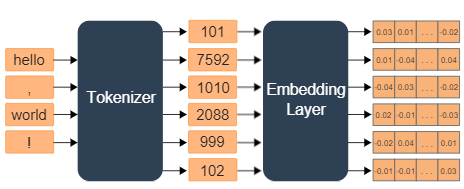

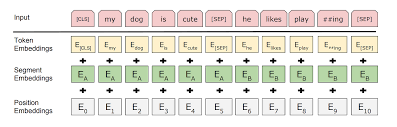

In [ ]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer, util
import numpy as np

texts = ["Revenue for the period went down", "Sales declined for the period"]

model_name = "sentence-transformers/all-MiniLM-L6-v2"
hf_embeddings = HuggingFaceEmbeddings(model_name=model_name,)
embds = hf_embeddings.embed_documents(texts)

model_name1 = "sentence-transformers/all-mpnet-base-v2"
hf_embeddings1 = HuggingFaceEmbeddings(model_name=model_name1,)
embds1 = hf_embeddings1.embed_documents(texts)

#Cosine
print(util.pytorch_cos_sim(embds[0], embds[1]))
print(np.inner(embds[0], embds[1]))

#Cosine
print(util.pytorch_cos_sim(embds1[0], embds1[1]))
print(np.inner(embds1[0], embds1[1]))

tensor([[0.6443]])
0.6443064427161049
tensor([[0.7993]])
0.7992947539337751


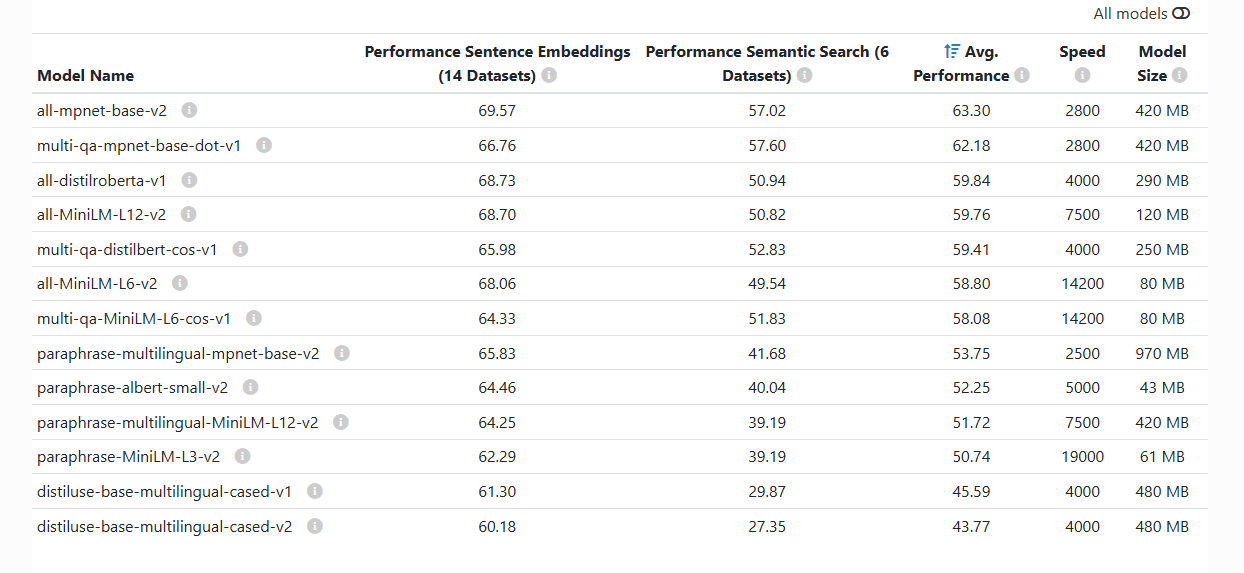

0


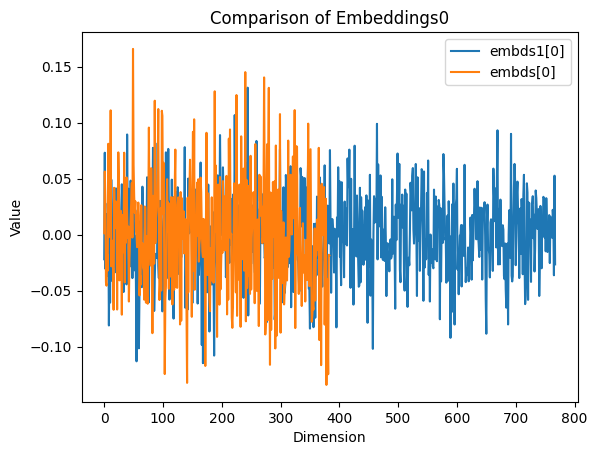

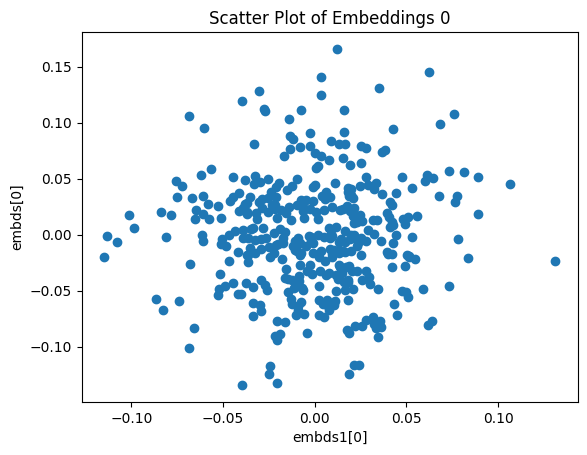

1


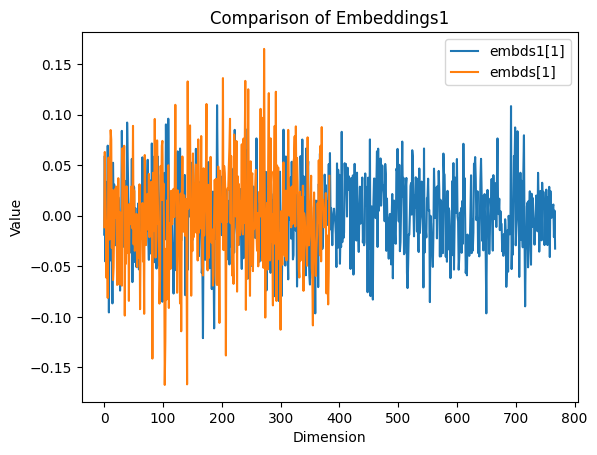

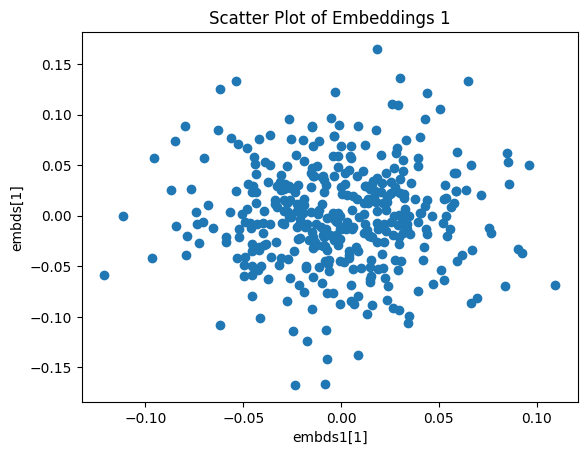

In [ ]:
import matplotlib.pyplot as plt

for i in range(0, 2):
  print(i)
  plt.plot(embds1[i], label=f'embds1[{i}]')
  plt.plot(embds[i], label=f'embds[{i}]')

  plt.xlabel('Dimension')
  plt.ylabel('Value')
  plt.title(f'Comparison of Embeddings{i}')
  plt.legend()
  plt.show()

  min_len = min(len(embds1[i]), len(embds[i]))  # Find the minimum length

  # Truncate the longer vector to match the length of the shorter one
  x = embds1[i][:min_len]
  y = embds[i][:min_len]

  plt.scatter(x, y)

  plt.xlabel(f'embds1[{i}]')
  plt.ylabel(f'embds[{i}]')
  plt.title(f'Scatter Plot of Embeddings {i}')
  plt.show()

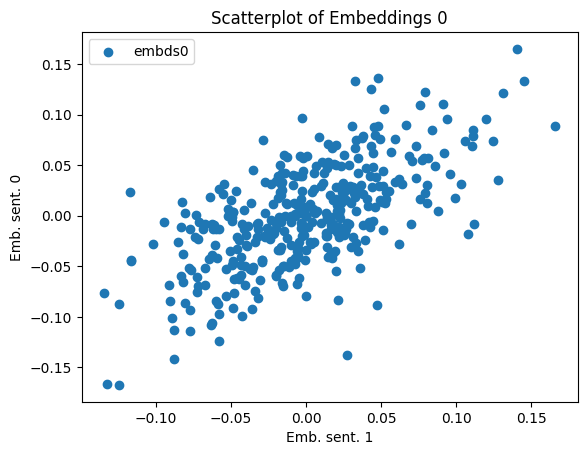

In [ ]:
plt.scatter(embds[0],embds[1], label=f'embds0')
plt.xlabel('Emb. sent. 1')
plt.ylabel('Emb. sent. 0')
plt.title(f'Scatterplot of Embeddings 0')
plt.legend()
plt.show()

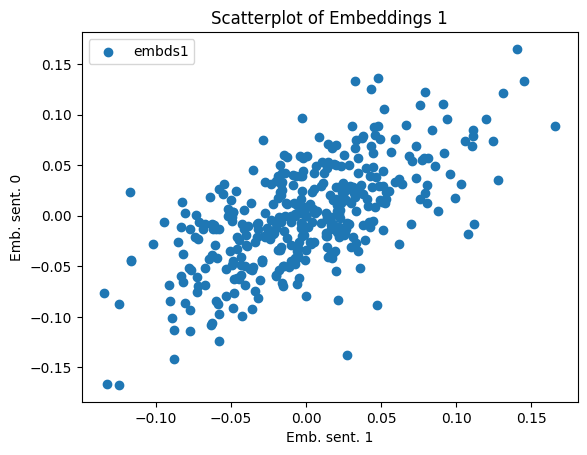

In [ ]:
plt.scatter(embds[0],embds[1], label=f'embds1')
plt.xlabel('Emb. sent. 1')
plt.ylabel('Emb. sent. 0')
plt.title(f'Scatterplot of Embeddings 1')
plt.legend()
plt.show()

# **SPLIT AND EMBEDDING of example PDF**

In [ ]:
from langchain.document_loaders import PyPDFLoader

#loader = PyPDFLoader("/content/drive/MyDrive/Colab Notebooks/text_mining/jd_guns.pdf")

#Load the document by calling loader.load()
docs= loader.load()

# Define the Text Splitter
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 200,
    chunk_overlap = 20,
    length_function = len,
    separators=["\n\n", "\n", " ", ""]
)

#Create a split of the document using the text splitter
splits = text_splitter.split_documents(docs)
splits

print("---Recursive CHARACTER SPLITTER")
# Print all elements of docs_charsplitter
for idx, doc in enumerate(splits[:min(6, len(splits))]):
    print(f"Chunk {idx + 1}:")
    print(doc)
    print("---")  # Add a separator between chunks


---Recursive CHARACTER SPLITTER
Chunk 1:
page_content='A SUITABLE STARTING POINT FROM WHICH TO COMPARE historical developments on the 
different continents is around 11,000 B.C.* This date corresponds approximately to the beginnings of' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 2:
page_content='village life in a few parts of the world, the first undisputed peopling of the Americas, the end of the' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 3:
page_content='Pleistocene Era and last Ice Age, and the start of what geologists term the Recent Era. Plant and animal' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 4:
page_content='domestication began in at least one part of the world within a few thousand years of that date. As of' metadata={'source': '/content/drive/MyDrive/text_mining/jd_guns.pdf', 'page': 0}
---
Chunk 5:
page_content='then, did the peo

In [ ]:
from langchain.vectorstores import Chroma
persist_directory = 'docs/chroma/'

# Create the vector store
vectordb = Chroma.from_documents(
    documents=splits,
    embedding=hf_embeddings,
    persist_directory=persist_directory
)

print(vectordb._collection.count())

194


Embedding without sentences_transformer

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Load model from HuggingFace Hub
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-mpnet-base-v2')
model = AutoModel.from_pretrained('sentence-transformers/all-mpnet-base-v2')

# Tokenize sentences
encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

# Compute token embeddings
with torch.no_grad():
    model_output = model(**encoded_input)

# Perform pooling
sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

# Normalize embeddings
sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)

print("Sentence embeddings:")
print(sentence_embeddings)

#Cosine
print(np.inner(sentence_embeddings[0], sentence_embeddings[1]))

Sentence embeddings:
tensor([[-0.0221,  0.0731, -0.0306,  ..., -0.0364,  0.0526, -0.0266],
        [-0.0187,  0.0592, -0.0452,  ..., -0.0210,  0.0051, -0.0325]])
0.7992947


# **QUERY on CHUCKS**

- similarity_search
- max_marginal_relevance_search (penalized closest to previous selected)

In [ ]:
question = "fossils of java"

docs = vectordb.similarity_search(question)
print(docs[0].page_content)


attested by fossils discovered on the Southeast Asian island of Java and conventionally known as Java


In [ ]:

found_sentences = await vectordb.amax_marginal_relevance_search(question, k=2, fetch_k=12)
for i, doc in enumerate(found_sentences):
    print(f"{i + 1}.", doc.page_content, "\n")

1. attested by fossils discovered on the Southeast Asian island of Java and conventionally known as Java 

2. By about half a million years ago, human fossils had diverged from older Homo erectus skeletons in 



# **Retrieval augmented generation (RAG) on Q&A using LLM**

### RAG Retrieval Augmented Generator for QA with embedding and LLM to query document and get a reply with different pretrained-LLM

*   load and split the document
*   sentence embedding "sentence-transformers/all-MiniLM-L6-v2"
*   test LLM pretrained model "microsoft/Phi-3-mini-4k-instruct" "openbmb/MiniCPM3-4B"
*   set Retrieval QA

https://python.langchain.com/v0.2/docs/concepts/#retrieval



In [ ]:
# Step 1: Import necessary libraries
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from langchain.llms.base import LLM
from langchain_huggingface import HuggingFacePipeline
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from typing import List
import os


def upload_file() -> str:
    """Allow file upload in Colab and return the uploaded file path."""
    from google.colab import files
    print("Please upload your PDF document.")
    uploaded = files.upload()
    file_name = next(iter(uploaded))  # Get the first uploaded file
    print(f"File uploaded: {file_name}")
    return file_name

def load_and_split_document(file_path: str) -> List:
    """Load and split the document into manageable chunks."""
    print(f"Loading document: {file_path}")
    loader = PyPDFLoader(file_path)
    pages = loader.load()

    print(f"Total pages loaded: {len(pages)}")
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
    return text_splitter.split_documents(pages)

def create_vector_store(documents: List) -> Chroma:
    """Create a vector store from document embeddings."""
    print("Generating embeddings...")
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    vectorstore = Chroma.from_documents(documents, embeddings)
    print("Embeddings generated and stored.")
    return vectorstore

def setup_huggingface_pipeline(model_choice: int = 0) -> LLM:
    """Set up the Hugging Face pipeline for question answering."""
    print("Setting up the Hugging Face QA pipeline...")

    # Select model based on the choice
    if model_choice == 0:
        model_id = "microsoft/Phi-3-mini-4k-instruct"
    else:
        #model_id = "microsoft/Phi-3.5-mini-instruct"
        model_id = "openbmb/MiniCPM3-4B"
    # Load the Hugging Face model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, load_in_4bit=True, trust_remote_code=True)
    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=50, top_k=5, temperature=0.01)
    llm = HuggingFacePipeline(pipeline=pipe)

    return llm

def build_qa_chain(vectorstore: Chroma, llm: LLM) -> RetrievalQA:
    """Build a question-answering chain using Hugging Face pipeline."""
    template = """Use the following pieces of context to answer the question at the end.
    If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum.
    Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer.
    //context
    {context}
    //question
    Question: {question}
    //answer
    Answer:"""
    QA_CHAIN_PROMPT = PromptTemplate.from_template(template)# Run chain
    retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})
    qa_chain = RetrievalQA.from_chain_type(
        retriever=retriever,
        llm=llm,
        return_source_documents=True,
        verbose=True,
        chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
    )
    return qa_chain

def ask_questions(qa_chain: RetrievalQA, question: str) -> None:
    """Interactive Q&A loop for user input."""
    print("Q&A system is running....")
    user_query = question
    try:
        # Get the full output (answer and source documents)
        output = qa_chain({"query": user_query})
        answer = output["result"]  # Extract the answer
        sources = output["source_documents"]  # Extract source documents

        print(f"\nAnswer: {answer}\n")
        print("Sources:")
        for source in sources:
            print(source.page_content[:500] + "...\n")  # Display the first 200 characters of each source document
    except Exception as e:
        print(f"Error: {e}")


In [ ]:
# Step 1: Upload the document
#file_path = "/content/drive/MyDrive/Colab Notebooks/text_mining/jd_guns.pdf"
file_path = "/content/drive/MyDrive/text_mining/jd_guns.pdf"


# Step 2: Load and split the document
documents = load_and_split_document(file_path)

# Step 3: Create vector store
vectorstore = create_vector_store(documents)

# Step 4: Set up Hugging Face pipeline
llm0 = setup_huggingface_pipeline(model_choice=0)
llm1 = setup_huggingface_pipeline(model_choice=1)


Loading document: /content/drive/MyDrive/text_mining/jd_guns.pdf
Total pages loaded: 4
Generating embeddings...
Embeddings generated and stored.
Setting up the Hugging Face QA pipeline...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
`low_cpu_mem_usage` was None, now default to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Setting up the Hugging Face QA pipeline...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
`low_cpu_mem_usage` was None, now default to True since model is quantized.


In [ ]:
question = 'What happens to Cro-Magnon?'
###########################################
#"microsoft/Phi-3-mini-4k-instruct"
# Step 5: Build the QA chain
qa_chain = build_qa_chain(vectorstore, llm0)

# Step 6: Start the Q&A session
ask_questions(qa_chain, question)

print('/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*')
###########################################
#"openbmb/MiniCPM3-4B"
# Step 5: Build the QA chain
qa_chain = build_qa_chain(vectorstore, llm1)

# Step 6: Start the Q&A session
ask_questions(qa_chain, question)


In [ ]:
question = 'What happens to Homo-Erectus?'
###########################################
#"microsoft/Phi-3-mini-4k-instruct"
# Step 5: Build the QA chain
qa_chain = build_qa_chain(vectorstore, llm0)

# Step 6: Start the Q&A session
ask_questions(qa_chain, question)

print('/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*')
###########################################
#"openbmb/MiniCPM3-4B"
# Step 5: Build the QA chain
qa_chain = build_qa_chain(vectorstore, llm1)

# Step 6: Start the Q&A session
ask_questions(qa_chain, question)


In [ ]:
question = 'Cro-Magnon was in Africa?'
###########################################
#"microsoft/Phi-3-mini-4k-instruct"
# Step 5: Build the QA chain
qa_chain = build_qa_chain(vectorstore, llm0)

# Step 6: Start the Q&A session
ask_questions(qa_chain, question)

print('/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*')
###########################################
#"openbmb/MiniCPM3-4B"
# Step 5: Build the QA chain
qa_chain = build_qa_chain(vectorstore, llm1)

# Step 6: Start the Q&A session
ask_questions(qa_chain, question)